# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [80]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [81]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

In [82]:
# mostrar las primeras 5 filas de plans
plans.describe()

,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
count,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
mean,300.000000,12.500000,350.000000,18.500000,1.100000,0.065000,0.085000
std,282.842712,10.606602,353.553391,9.192388,0.141421,0.021213,0.021213
min,100.000000,5.000000,100.000000,12.000000,1.000000,0.050000,0.070000
25%,200.000000,8.750000,225.000000,15.250000,1.050000,0.057500,0.077500
50%,300.000000,12.500000,350.000000,18.500000,1.100000,0.065000,0.085000
75%,400.000000,16.250000,475.000000,21.750000,1.150000,0.072500,0.092500
max,500.000000,20.000000,600.000000,25.000000,1.200000,0.080000,0.100000


In [83]:
# mostrar las primeras 5 filas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [84]:
# mostrar las primeras 5 filas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [85]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [86]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [87]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [88]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [89]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [90]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.
    - En el caso de users, tenemos en la columna de City un 11% de valores faltantes, por lo que tenemos que investigarlo para saber si lo imputamos o dejamos como nulos. Y en Churn_date el porcentaje es de 88% por lo que probablemente la información no sea relevante para el anñalisis, por lo que se eliminaría
    - Ahora en el caso de usage, la columna date presenta un porcentaje mínimo, que no se debe de considerar en lo absoluto. Duration tiene un porcentaje del 55%, mientras que Lenght 44%, ambos casos se tienen que investigar para poder decidir que hacer con los datos faltantes


💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [91]:
# explorar columnas numéricas de users
for col in ["age", "user_id"]:
    print(f"\nValores únicos en {col}:")
    print(users[col].value_counts())


Valores únicos en age:
50    86
30    81
78    79
33    74
36    74
      ..
57    54
51    54
62    51
68    51
70    45
Name: age, Length: 63, dtype: int64

Valores únicos en user_id:
10241    1
11583    1
13604    1
11559    1
13608    1
        ..
10916    1
12967    1
10920    1
12971    1
10239    1
Name: user_id, Length: 4000, dtype: int64


- La columna `user_id` muestra que ninguno se repite. Todos son valores unicos
- La columna `age` nos muestra un resultado normal, sin edades improbables y valores consistentes entre edades

In [92]:
# explorar columnas numéricas de usage
for col in ["id", "user_id", "duration", "length"]:
    print(f"\nValores únicos en {col}:")
    print(usage[col].value_counts())


Valores únicos en id:
2049     1
35492    1
25241    1
31386    1
29339    1
        ..
17730    1
19779    1
30020    1
32069    1
2047     1
Name: id, Length: 40000, dtype: int64

Valores únicos en user_id:
13819    27
13100    22
13772    22
13255    22
13475    21
         ..
12448     2
11891     2
10226     2
13923     2
12058     1
Name: user_id, Length: 3999, dtype: int64

Valores únicos en duration:
0.21     47
0.03     43
1.25     43
0.02     43
0.84     43
         ..
46.69     1
42.73     1
17.42     1
21.79     1
16.02     1
Name: duration, Length: 2090, dtype: int64

Valores únicos en length:
47.0     460
51.0     457
53.0     456
45.0     455
50.0     452
        ... 
125.0      1
116.0      1
123.0      1
119.0      1
111.0      1
Name: length, Length: 123, dtype: int64


- La columna `id` muestra valores unicos en todas sus entradas, mientras que en `user_id` podemos ver muchos valores que se repiten muchas veces
- Tanto en la columna `duration` como en `length`, podemos ver valores que se repiten de manera normal

In [93]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\nValores únicos en {col}:")
    print(users[col].value_counts())


Valores únicos en city:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Valores únicos en plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` nos muestra una fila perteneciente a ninguna ciudad, con nombre "?"
- La columna `plan` nos muestra unicamente dos tipos de planes

In [94]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` muestra 2 entradas, text y call

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  En la columna CITY encontre una fila con nombre "?" donde tenemos 96 datos
- ¿Qué acción tomarías?  Se tiene que analizar para poder decidir como manejar esos datos 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [95]:
# Convertir a fecha la columna `reg_date` de users
users["reg_date"] = pd.to_datetime(users["reg_date"])

In [96]:
# Convertir a fecha la columna `date` de usage
usage["date"] = pd.to_datetime(usage["date"])

In [97]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, podemos ver que hay 4 años en nuestro registro, pero siguiendo el orden cronológico, nos falta el año 2025

In [98]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, unicamente tenemos el registro del 2024, pero está con decimales. Por lo que se tiene que cambiar de formato  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? No tenemos años imposibles. Lo que si, hay un missingness del año 2025 en USERS y el año 2024 en USAGE no está con el dtype correcto
- ¿Qué harías con ellas? Se tiene que revisar si el año faltante es importante para el analisis y ver que se puede corregir. Y para el año en diferente dtype, simplemente converir al correcto.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [99]:
# Reemplazar -999 por la mediana de age
age_mediana = users["age"].median()
users['age'] = users["age"].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [100]:

# Reemplazar ? por NA en city
users["city"] = users["city"].replace("?", np.nan)


# Verificar cambios
users["city"].describe()


count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [101]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2026, 'reg_date'] = pd.NaT

# Verificar cambios
print(f"Valores nulos en reg_date: {users['reg_date'].isna().sum()}")

Valores nulos en reg_date: 0


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [102]:
# Verificación MAR en usage (Missing At Random) para duration
print("=== ANÁLISIS DE DURATION ===")
duration_analysis = usage.groupby('type')['duration'].agg(['count', lambda x: x.isna().sum(), 'size'])
duration_analysis.columns = ['no_nulos', 'nulos', 'total']
duration_analysis['porcentaje_nulos'] = (duration_analysis['nulos'] / duration_analysis['total']) * 100
print(duration_analysis)

=== ANÁLISIS DE DURATION ===
      no_nulos    nulos  total  porcentaje_nulos
type                                            
call     17908      0.0  17908          0.000000
text        16  22076.0  22092         99.927576


In [103]:
# Verificación MAR en usage (Missing At Random) para length
print("\n=== ANÁLISIS DE LENGTH ===")
length_analysis = usage.groupby('type')['length'].agg(['count', lambda x: x.isna().sum(), 'size'])
length_analysis.columns = ['no_nulos', 'nulos', 'total']
length_analysis['porcentaje_nulos'] = (length_analysis['nulos'] / length_analysis['total']) * 100
print(length_analysis)


=== ANÁLISIS DE LENGTH ===
      no_nulos    nulos  total  porcentaje_nulos
type                                            
call        12  17896.0  17908         99.932991
text     22092      0.0  22092          0.000000


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

- Dado la naturaleza de cada tipo, los valores faltantes no son errores en la calidad de datos, sino que son missingness logicos. Por lo que no hace falta imputar o eliminar estos valores.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
  
3. Combina esta tabla con `users`.

In [104]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas
usage["is_duration"] = usage["duration"].where(usage["type"] == "call", 0) #conocer el total de minutos de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(cant_mensajes = ("is_text", "sum"), cant_llamadas = ("is_call", "sum"), cant_minutos_llamada = ("is_duration", "sum")).reset_index()

# observar resultado
usage_agg.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74
3,10003,11,3,8.99
4,10004,4,3,8.01


In [105]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on= "user_id", how= "left")
user_profile.head(10)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01
5,10005,Luis,Garcia,61.0,MTY,2022-01-02 08:51:29.572393098,Basico,NaN,5.0,7.0,44.97
6,10006,Sofia,Lopez,39.0,Bogotá,2022-01-02 15:25:47.486871717,Basico,NaN,3.0,5.0,28.39
7,10007,Sofia,Gomez,70.0,Medellín,2022-01-02 22:00:05.401350337,Premium,NaN,3.0,5.0,30.23
8,10008,Sofia,Garcia,76.0,CDMX,2022-01-03 04:34:23.315828957,Basico,NaN,5.0,5.0,28.85
9,10009,Mateo,Torres,47.0,Bogotá,2022-01-03 11:08:41.230307576,Basico,NaN,5.0,3.0,5.99


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [106]:
# Resumen estadístico de las columnas numéricas
users.describe(include= "all")

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
count,4000.000000,4000,4000,4000.000000,3435,4000,4000,466
unique,NaN,6,5,NaN,6,3961,2,197
top,NaN,Carlos,Lopez,NaN,Bogotá,2026-05-10 00:00:00,Basico,"1,72238E+18"
freq,NaN,685,835,NaN,808,40,2595,6
first,NaN,NaN,NaN,NaN,NaN,2022-01-01 00:00:00,NaN,NaN
last,NaN,NaN,NaN,NaN,NaN,2026-05-10 00:00:00,NaN,NaN
mean,11999.500000,NaN,NaN,48.122250,NaN,NaN,NaN,NaN
std,1154.844867,NaN,NaN,17.690408,NaN,NaN,NaN,NaN
min,10000.000000,NaN,NaN,18.000000,NaN,NaN,NaN,NaN
25%,10999.750000,NaN,NaN,33.000000,NaN,NaN,NaN,NaN


In [107]:
# Distribución porcentual del tipo de plan
users["plan"].value_counts(normalize= True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

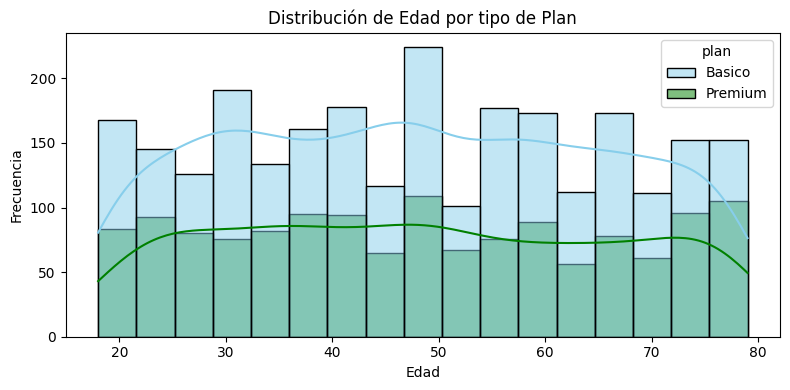

In [108]:
# Histograma para visualizar la edad (age)
fig, ax= plt.subplots(figsize= (8,4))
sns.histplot(data= user_profile, x= "age", hue= "plan", kde= True, palette=['skyblue','green'], ax= ax)
ax.set_title("Distribución de Edad por tipo de Plan")
ax.set_xlabel("Edad")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

💡Insights: 
- Podemos observar que el plan básico se concentra en mayor medida entre los 50 años de edad. Mientras que para el plan premium, se distribuye casi de manera equitativa

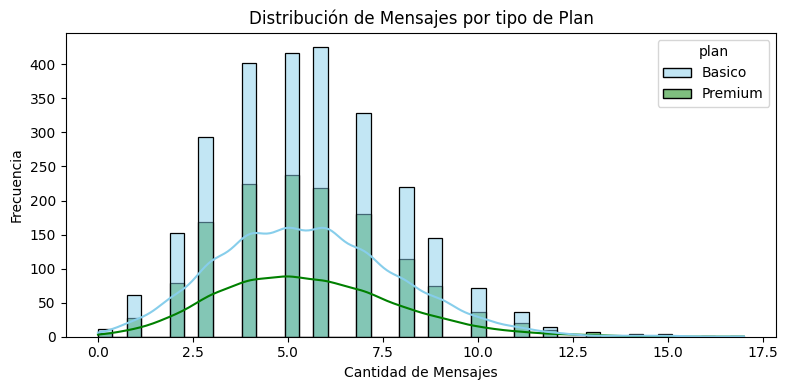

In [109]:
# Histograma para visualizar la cant_mensajes
fig, ax= plt.subplots(figsize= (8,4))
sns.histplot(data= user_profile, x= "cant_mensajes", hue= "plan", kde= True, palette=['skyblue','green'], ax= ax)
ax.set_title("Distribución de Mensajes por tipo de Plan")
ax.set_xlabel("Cantidad de Mensajes")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

💡Insights: 
- La mayor cantidad de mensajes promedio, ya se con el plan Basico o con el Premium, se concentra entre los 2.5 y 7.5

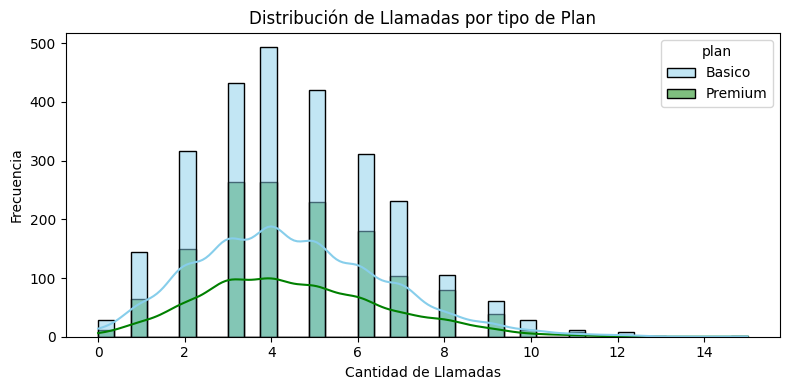

In [110]:
# Histograma para visualizar la cant_llamadas
fig, ax= plt.subplots(figsize= (8,4))
sns.histplot(data= user_profile, x= "cant_llamadas", hue= "plan", kde= True, palette=['skyblue','green'], ax= ax)
ax.set_title("Distribución de Llamadas por tipo de Plan")
ax.set_xlabel("Cantidad de Llamadas")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

💡Insights: 
- Vemos una distribución normal de campana donde la mayoria se concentre entre las 3 y 6 llamadas por usuario. Igual independientemente de si tienen plan Basico o Premium

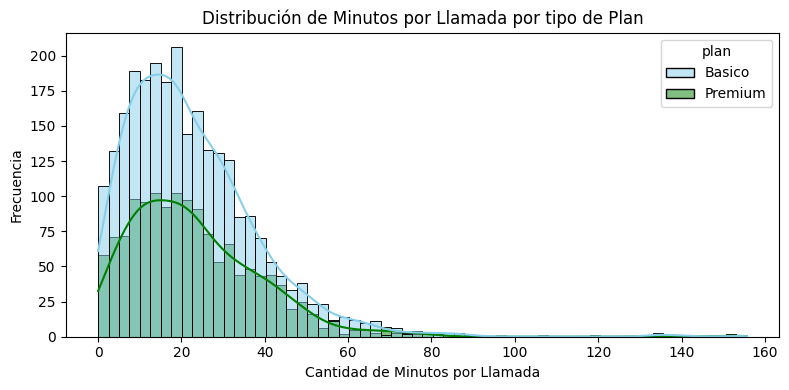

In [111]:
# Histograma para visualizar la cant_minutos_llamada
fig, ax= plt.subplots(figsize= (8,4))
sns.histplot(data= user_profile, x= "cant_minutos_llamada", hue= "plan", kde= True, palette=['skyblue','green'], ax= ax)
ax.set_title("Distribución de Minutos por Llamada por tipo de Plan")
ax.set_xlabel("Cantidad de Minutos por Llamada")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

💡Insights: 
- Vemos un grafico sesgado a la derecha, donde la cantidad de minutos promedio por llamada van de los 0min a los 20min, donde llegan a su máximo y de ahi empiezan a bajar hasta los 50min por llamada

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

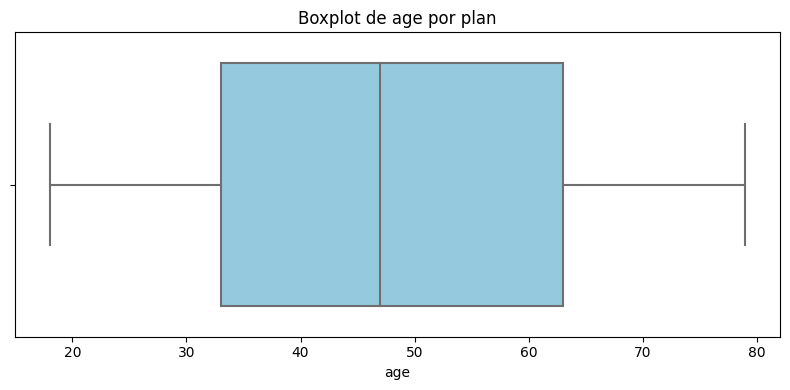

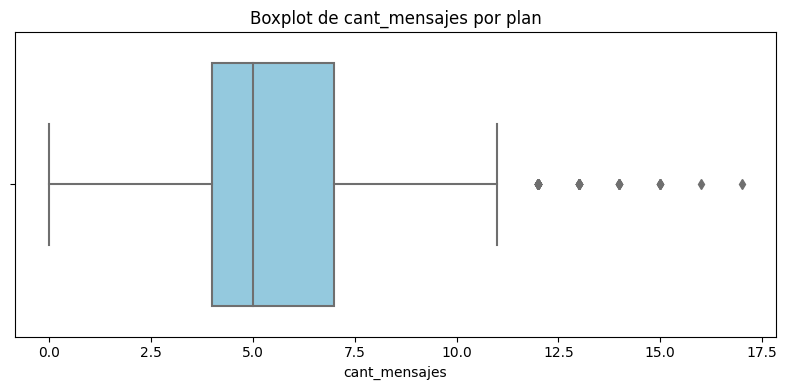

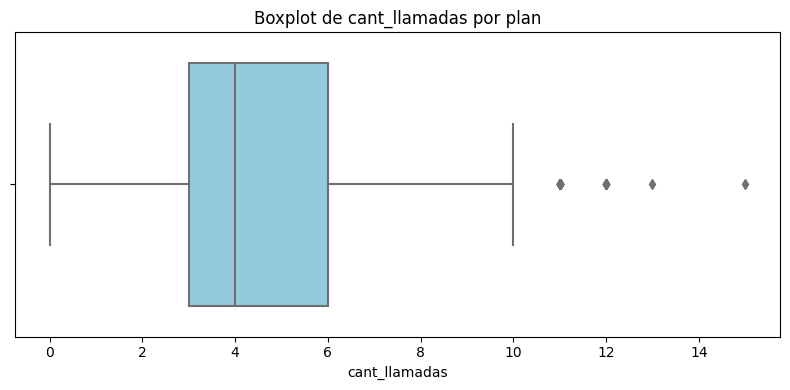

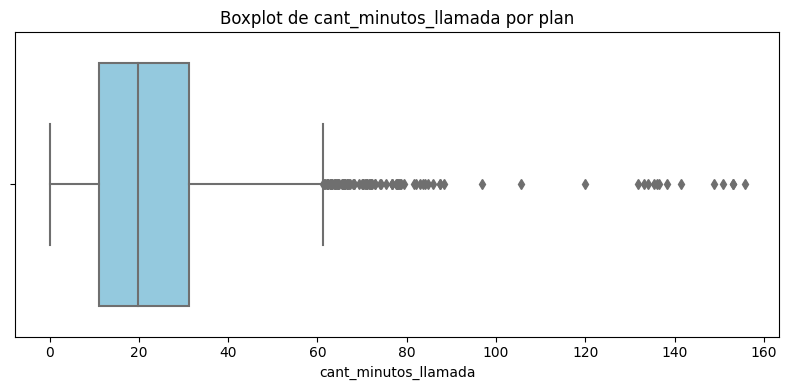

In [112]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.boxplot(data= user_profile, x=col, hue="plan", palette=["skyblue", "green"], ax=ax)
    ax.set_title(f"Boxplot de {col} por plan")
    ax.set_xlabel(col)
    plt.tight_layout()
    plt.show()

💡Insights: 
- Age: ...(presenta o no outliers)
- cant_mensajes: ...
- cant_llamadas: ...
- cant_minutos_llamada: ...

In [113]:
# Calcular límites con el método IQR
columnas_limites = ["age", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_derecho = Q3 + 1.5 * IQR
    
    outliers = user_profile[user_profile[col] > limite_derecho]
    porcentaje = (len(outliers) / len(user_profile)) * 100
    
    print(f"--- {col} ---")
    print(f"Q1: {Q1} | Q3: {Q3} | IQR: {IQR}")
    print(f"Límite derecho: {limite_derecho:.2f}")
    print(f"Cantidad de outliers: {len(outliers)}")
    print(f"Porcentaje: {porcentaje:.2f}%")
    print()


--- age ---
Q1: 33.0 | Q3: 63.0 | IQR: 30.0
Límite derecho: 108.00
Cantidad de outliers: 0
Porcentaje: 0.00%

--- cant_mensajes ---
Q1: 4.0 | Q3: 7.0 | IQR: 3.0
Límite derecho: 11.50
Cantidad de outliers: 46
Porcentaje: 1.15%

--- cant_llamadas ---
Q1: 3.0 | Q3: 6.0 | IQR: 3.0
Límite derecho: 10.50
Cantidad de outliers: 30
Porcentaje: 0.75%

--- cant_minutos_llamada ---
Q1: 11.094999999999999 | Q3: 31.185 | IQR: 20.09
Límite derecho: 61.32
Cantidad de outliers: 96
Porcentaje: 2.40%



In [114]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,22.836934
std,17.690408,2.358416,2.144238,16.590213
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.095000
50%,47.000000,5.000000,4.000000,19.740000
75%,63.000000,7.000000,6.000000,31.185000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 

-Podemos eliminar los outliers de las 3 columnas que cuentan con, ya que corresponen a menos del 3% de los datos. Aunque en cant_minutos_llamadas si tenemos un maximo de 155min por llamada, lo que es un caso aislado, confirmando que se puede eliminar y no afectará en el análisis.

In [121]:
columnas = ["age", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]

for col in columnas:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_derecho = Q3 + 1.5 * IQR
    
    user_profile = user_profile[user_profile[col] <= limite_derecho]

print(f"Filas después de eliminar outliers: {len(user_profile)}")

Filas después de eliminar outliers: 3833


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [124]:
# Crear columna grupo_uso
for i, row in user_profile.iterrows():
    if row["cant_llamadas"] < 5 and row["cant_mensajes"] < 5:
        user_profile.loc[i, "grupo_uso"] = "Bajo uso"
    elif row["cant_llamadas"] < 10 and row["cant_mensajes"] < 10:
        user_profile.loc[i, "grupo_uso"] = "Uso medio"
    else:
        user_profile.loc[i, "grupo_uso"] = "Alto uso"

In [125]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [126]:
# Crear columna grupo_edad
for i, row in user_profile.iterrows():
    if row["age"] < 30:
        user_profile.loc[i, "grupo_edad"] = "Joven"
    elif row["age"] < 60:
        user_profile.loc[i, "grupo_edad"] = "Adulto"
    else:
        user_profile.loc[i, "grupo_edad"] = "Adulto Mayor"

In [128]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

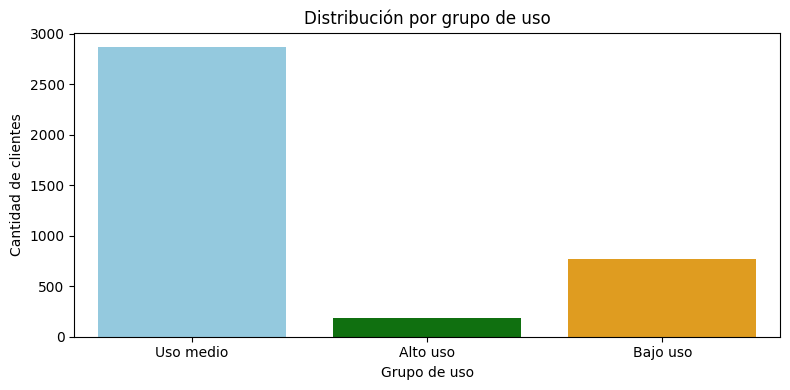

In [129]:
# Visualización de los segmentos por uso
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=user_profile, x="grupo_uso", palette=["skyblue", "green", "orange"], ax=ax)
ax.set_title("Distribución por grupo de uso")
ax.set_xlabel("Grupo de uso")
ax.set_ylabel("Cantidad de clientes")
plt.tight_layout()
plt.show()

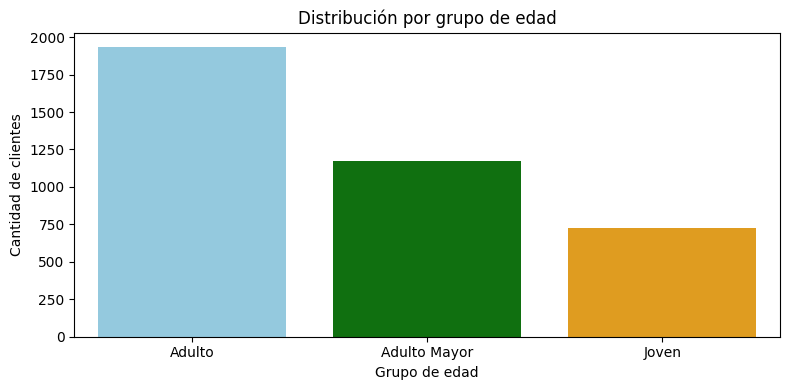

In [130]:
# Visualización de los segmentos por edad
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=user_profile, x="grupo_edad", palette=["skyblue", "green", "orange"], ax=ax)
ax.set_title("Distribución por grupo de edad")
ax.set_xlabel("Grupo de edad")
ax.set_ylabel("Cantidad de clientes")
plt.tight_layout()
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Para user_id, la columna CITY tenia 469 valores nulos, lo que representaba un 11% del total. Los cuales fueron luego reemplazados para poder tener un mejor análisis.
- Mientras que para CHURN_DATE, se tenian 3534 valores nulos, un 88% del total. Por lo que se decidió directamente ignorarlos, ya que al ser tantos, no aportaban valor real al análisis.
- De igual manera, DURATION y LENGTH mostraban un 55% y 44% de valores nulos respectivamente. Pero esto debido a la naturaleza de los datos que lo conforman, por lo que no representaban un problema


🔍 **Segmentos por Edad**
- No importa la edad, los datos se distribuían casi de manera uniforme entre los dos planes que se manejan.
- Aunque se ve una dominación clara en gente Adulta entre los 30 y 60 años, los cuales representan casi el 50% del total de usuarios.



📊 **Segmentos por Nivel de Uso**
- Al rededor del 92% de los usuarios se reportan dentro de un Uso Medio teniendo como contraparte un Alto uso, con apenas un 6%


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- Se debería de aprovechar al segmento de adultos para poder hacer mas promociones en ese sector y atraer más clientes
- De igual manera, se podría manejar un plan con menores beneficios en texto y llamada, ya que dificilmente se usa todo lo que contiene un plan basico y premium actual en terminos de llamadas y texto. 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`

In [120]:
#https://github.com/EXDDimanche/Analisis-ConectaTel